In [1]:
"""
============================================================================
Task 5: Machine Translation (English → Kannada) using Transformer Model
============================================================================
- Transformer Encoder with 3 layers
- Transformer Decoder with 3 layers
- Multi-Head Attention (4 heads)
- Sinusoidal Positional Encoding
- GloVe word embeddings for English (200d)
- FastText word embeddings for Kannada (200d)
- BLEU-1, 2, 3, 4 evaluation
- 5 training + 5 test example translations
============================================================================
"""

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import csv
import time
import os
import math
from collections import Counter
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

# ============================================================================
# CONFIGURATION
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

SOS_token = 0
EOS_token = 1
UNK_token = 2
PAD_token = 3

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Hyperparameters
EMB_DIM = 200
D_MODEL = 256
N_HEADS = 4
N_ENCODER_LAYERS = 3
N_DECODER_LAYERS = 3
D_FF = 512
DROPOUT = 0.1
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
EPOCHS = 20
MAX_LEN = 20
MIN_FREQ = 2
WARMUP_STEPS = 2000  # ~2 epochs with 984 batches/epoch

# File paths
TRAIN_FILE = "/content/team23_kn_train.csv"
TEST_FILE = "/content/team23_kn_test.csv"
GLOVE_FILE = "/content/glove.6B.200d.txt"
FASTTEXT_FILE = "/content/wiki.kn.vec"

# ============================================================================
# VOCABULARY
# ============================================================================
class Lang:
    def __init__(self, name, min_freq=2):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "UNK": 2, "PAD": 3}
        self.index2word = {0: "SOS", 1: "EOS", 2: "UNK", 3: "PAD"}
        self.word2count = Counter()
        self.n_words = 4
        self.min_freq = min_freq

    def build_vocab(self, sentences):
        for s in sentences:
            for w in s.split():
                self.word2count[w] += 1
        for word, count in self.word2count.items():
            if count >= self.min_freq:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1
        print(f"  {self.name} vocab: {self.n_words} words "
              f"(filtered from {len(self.word2count)} unique, min_freq={self.min_freq})")

# ============================================================================
# DATA LOADING
# ============================================================================
def read_pairs(filepath):
    pairs = []
    with open(filepath, encoding='utf-8') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) >= 2:
                src = row[0].strip().lower()
                tgt = row[1].strip()
                if src and tgt:
                    pairs.append((src, tgt))
    return pairs

def filter_pairs(pairs, max_len):
    return [(s, t) for s, t in pairs
            if 2 <= len(s.split()) <= max_len and 2 <= len(t.split()) <= max_len]

def sentence_to_indices(lang, sentence):
    return [lang.word2index.get(w, UNK_token) for w in sentence.split()] + [EOS_token]

# ============================================================================
# DATASET & DATALOADER
# ============================================================================
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_lang, tgt_lang):
        self.data = []
        for src, tgt in pairs:
            src_ids = torch.tensor(sentence_to_indices(src_lang, src), dtype=torch.long)
            tgt_ids = torch.tensor(sentence_to_indices(tgt_lang, tgt), dtype=torch.long)
            self.data.append((src_ids, tgt_ids))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs])
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_token)
    tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=PAD_token)
    return srcs_padded.to(DEVICE), tgts_padded.to(DEVICE), src_lens.to(DEVICE)

# ============================================================================
# PRETRAINED EMBEDDINGS
# ============================================================================
def load_glove(filepath, vocab, dim=200):
    if not os.path.exists(filepath):
        print(f"  GloVe not found at {filepath}, using random init")
        return None
    print(f"  Loading GloVe from {filepath}...")
    embeddings = {}
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            if word in vocab.word2index:
                embeddings[word] = np.asarray(values[1:], dtype='float32')
    matrix = np.random.normal(scale=0.1, size=(vocab.n_words, dim)).astype('float32')
    found = 0
    for word, idx in vocab.word2index.items():
        if word in embeddings:
            matrix[idx] = embeddings[word]
            found += 1
    print(f"  Found {found}/{vocab.n_words} words in GloVe")
    return torch.tensor(matrix, dtype=torch.float)

def load_fasttext(filepath, vocab, dim=200):
    if not os.path.exists(filepath):
        print(f"  FastText not found at {filepath}, using random init")
        return None
    print(f"  Loading FastText from {filepath}...")
    embeddings = {}
    with open(filepath, encoding='utf-8') as f:
        first_line = f.readline().strip().split()
        if len(first_line) != 2:
            f.seek(0)
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            if word in vocab.word2index:
                try:
                    embeddings[word] = np.asarray(values[1:dim+1], dtype='float32')
                except ValueError:
                    continue
    matrix = np.random.normal(scale=0.1, size=(vocab.n_words, dim)).astype('float32')
    found = 0
    for word, idx in vocab.word2index.items():
        if word in embeddings and len(embeddings[word]) == dim:
            matrix[idx] = embeddings[word]
            found += 1
    print(f"  Found {found}/{vocab.n_words} words in FastText")
    return torch.tensor(matrix, dtype=torch.float)

# ============================================================================
# MODEL
# ============================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)
    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.W_q(query).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.W_o(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
    def forward(self, src, src_mask=None):
        src = self.norm1(src + self.drop1(self.self_attn(src, src, src, src_mask)))
        src = self.norm2(src + self.drop2(self.ffn(src)))
        return src

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.drop3 = nn.Dropout(dropout)
    def forward(self, tgt, enc_out, tgt_mask=None, src_mask=None):
        tgt = self.norm1(tgt + self.drop1(self.self_attn(tgt, tgt, tgt, tgt_mask)))
        tgt = self.norm2(tgt + self.drop2(self.cross_attn(tgt, enc_out, enc_out, src_mask)))
        tgt = self.norm3(tgt + self.drop3(self.ffn(tgt)))
        return tgt

class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb_dim, d_model, n_heads, d_ff,
                 n_enc_layers, n_dec_layers, dropout=0.1, src_emb=None, tgt_emb=None):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = PAD_token
        self.src_embedding = nn.Embedding(src_vocab, emb_dim, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(tgt_vocab, emb_dim, padding_idx=PAD_token)
        if src_emb is not None:
            self.src_embedding.weight.data.copy_(src_emb)
        if tgt_emb is not None:
            self.tgt_embedding.weight.data.copy_(tgt_emb)
        self.src_proj = nn.Linear(emb_dim, d_model) if emb_dim != d_model else nn.Identity()
        self.tgt_proj = nn.Linear(emb_dim, d_model) if emb_dim != d_model else nn.Identity()
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout)
                                         for _ in range(n_enc_layers)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout)
                                         for _ in range(n_dec_layers)])
        self.fc_out = nn.Linear(d_model, tgt_vocab)
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2).to(src.device)

    def make_tgt_mask(self, tgt):
        B, T = tgt.shape
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        causal_mask = torch.tril(torch.ones((T, T), device=tgt.device)).bool().unsqueeze(0).unsqueeze(1)
        return pad_mask & causal_mask

    def encode(self, src, src_mask):
        x = self.src_proj(self.src_embedding(src)) * math.sqrt(self.d_model)
        x = self.pos_enc(x)
        for layer in self.enc_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.tgt_proj(self.tgt_embedding(tgt)) * math.sqrt(self.d_model)
        x = self.pos_enc(x)
        for layer in self.dec_layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return self.fc_out(x)

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        return self.decode(tgt, enc_out, tgt_mask, src_mask)

# ============================================================================
# TRAINING
# ============================================================================
def train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0
    n_batches = 0
    for src, tgt, src_lens in loader:
        optimizer.zero_grad()
        B = tgt.size(0)
        sos = torch.full((B, 1), SOS_token, dtype=torch.long, device=DEVICE)
        dec_input = torch.cat([sos, tgt[:, :-1]], dim=1)
        output = model(src, dec_input)
        output = output.contiguous().view(-1, output.size(-1))
        tgt_flat = tgt.contiguous().view(-1)
        loss = criterion(output, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

# ============================================================================
# TRANSLATION
# ============================================================================
def translate(model, sentence, src_lang, tgt_lang, max_len=50):
    model.eval()
    with torch.no_grad():
        src_ids = sentence_to_indices(src_lang, sentence)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
        src_mask = model.make_src_mask(src_tensor)
        enc_out = model.encode(src_tensor, src_mask)
        dec_input = torch.tensor([[SOS_token]], dtype=torch.long, device=DEVICE)
        result = []
        for _ in range(max_len):
            tgt_mask = model.make_tgt_mask(dec_input)
            output = model.decode(dec_input, enc_out, tgt_mask, src_mask)
            next_token = output[:, -1, :].argmax(dim=-1)
            word_idx = next_token.item()
            if word_idx == EOS_token:
                break
            word = tgt_lang.index2word.get(word_idx, None)
            if word and word not in ("UNK", "PAD", "SOS", "EOS"):
                result.append(word)
            dec_input = torch.cat([dec_input, next_token.unsqueeze(0)], dim=1)
    return " ".join(result)

# ============================================================================
# BLEU SCORE
# ============================================================================
def compute_bleu(pairs, model, src_lang, tgt_lang, n_samples=500):
    pairs = pairs[:n_samples]
    precisions = {1: [], 2: [], 3: [], 4: []}
    for src, tgt in pairs:
        hypothesis = translate(model, src, src_lang, tgt_lang).split()
        reference = tgt.split()
        for n in range(1, 5):
            if len(hypothesis) < n:
                precisions[n].append(0.0)
                continue
            ref_ngrams = Counter()
            hyp_ngrams = Counter()
            for i in range(len(reference) - n + 1):
                ref_ngrams[tuple(reference[i:i+n])] += 1
            for i in range(len(hypothesis) - n + 1):
                hyp_ngrams[tuple(hypothesis[i:i+n])] += 1
            clipped = sum(min(count, ref_ngrams.get(ng, 0))
                         for ng, count in hyp_ngrams.items())
            total = max(sum(hyp_ngrams.values()), 1)
            precisions[n].append(clipped / total)
    return {k: np.mean(v) for k, v in precisions.items()}

# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("Task 5: English → Kannada Machine Translation using Transformer")
    print("       (3 Encoder Layers + 3 Decoder Layers)")
    print("=" * 70)

    print("\n[1] Loading data...")
    train_pairs = read_pairs(TRAIN_FILE)
    test_pairs = read_pairs(TEST_FILE)
    print(f"  Raw: train={len(train_pairs)}, test={len(test_pairs)}")
    train_pairs = filter_pairs(train_pairs, MAX_LEN)
    test_pairs = filter_pairs(test_pairs, MAX_LEN)
    print(f"  Filtered (≤{MAX_LEN} words): train={len(train_pairs)}, test={len(test_pairs)}")

    print("\n[2] Building vocabularies...")
    src_lang = Lang("English", min_freq=MIN_FREQ)
    tgt_lang = Lang("Kannada", min_freq=MIN_FREQ)
    src_lang.build_vocab([p[0] for p in train_pairs])
    tgt_lang.build_vocab([p[1] for p in train_pairs])

    print("\n[3] Loading embeddings...")
    src_emb = load_glove(GLOVE_FILE, src_lang, EMB_DIM)
    tgt_emb = load_fasttext(FASTTEXT_FILE, tgt_lang, EMB_DIM)

    print("\n[4] Creating data loaders...")
    train_dataset = TranslationDataset(train_pairs, src_lang, tgt_lang)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, collate_fn=collate_fn)
    n_batches = len(train_loader)
    print(f"  {n_batches} batches per epoch")
    print(f"  Warmup: {WARMUP_STEPS} steps (~{WARMUP_STEPS/n_batches:.1f} epochs)")

    print("\n[5] Building Transformer model...")
    print(f"  d_model={D_MODEL}, n_heads={N_HEADS}, d_ff={D_FF}")
    print(f"  Encoder layers: {N_ENCODER_LAYERS}, Decoder layers: {N_DECODER_LAYERS}")

    model = Transformer(
        src_vocab=src_lang.n_words, tgt_vocab=tgt_lang.n_words,
        emb_dim=EMB_DIM, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
        n_enc_layers=N_ENCODER_LAYERS, n_dec_layers=N_DECODER_LAYERS,
        dropout=DROPOUT, src_emb=src_emb, tgt_emb=tgt_emb
    ).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Total params: {total_params:,}")

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)

    # Warmup then constant LR — scheduler steps EVERY batch
    def lr_lambda(step):
        step = max(step, 1)
        if step < WARMUP_STEPS:
            return step / WARMUP_STEPS
        return 1.0
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    print("\n" + "=" * 70)
    print("TRAINING")
    print("=" * 70)

    best_bleu1 = 0
    loss_history = []   # ✅ store loss

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        avg_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            scheduler
        )

        loss_history.append(avg_loss)   # ✅ store loss

        elapsed = time.time() - t0

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
            bleu = compute_bleu(test_pairs, model, src_lang, tgt_lang, 300)
            lr = optimizer.param_groups[0]['lr']

            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | LR: {lr:.6f} | "
                  f"BLEU-1: {bleu[1]:.4f} | BLEU-2: {bleu[2]:.4f} | "
                  f"BLEU-3: {bleu[3]:.4f} | BLEU-4: {bleu[4]:.4f} | {elapsed:.1f}s")

            if bleu[1] > best_bleu1:
                best_bleu1 = bleu[1]
                torch.save({'model': model.state_dict()}, 'best_model_task5.pt')
                print("  → New best! Saved model.")
        else:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | {elapsed:.1f}s")

    ckpt = torch.load('best_model_task5.pt', weights_only=False)
    model.load_state_dict(ckpt['model'])

    print("\n" + "=" * 70)
    print("FINAL TEST SET EVALUATION")
    print("=" * 70)
    final_bleu = compute_bleu(test_pairs, model, src_lang, tgt_lang, 500)
    print(f"\n  BLEU-1: {final_bleu[1]:.4f}")
    print(f"  BLEU-2: {final_bleu[2]:.4f}")
    print(f"  BLEU-3: {final_bleu[3]:.4f}")
    print(f"  BLEU-4: {final_bleu[4]:.4f}")

    print("\n" + "=" * 70)
    print("5 TRAINING EXAMPLES")
    print("=" * 70)
    for i, (src, tgt) in enumerate(random.sample(train_pairs, 5), 1):
        pred = translate(model, src, src_lang, tgt_lang)
        print(f"\n  Example {i}:")
        print(f"    Source (English) : {src}")
        print(f"    Ground Truth (KN): {tgt}")
        print(f"    Predicted (KN)   : {pred}")

    print("\n" + "=" * 70)
    print("5 TEST EXAMPLES")
    print("=" * 70)
    for i, (src, tgt) in enumerate(random.sample(test_pairs[:500], 5), 1):
        pred = translate(model, src, src_lang, tgt_lang)
        print(f"\n  Example {i}:")
        print(f"    Source (English) : {src}")
        print(f"    Ground Truth (KN): {tgt}")
        print(f"    Predicted (KN)   : {pred}")

    print("\n" + "=" * 70)
    print("DONE!")
    print("=" * 70)

Device: cuda
Task 5: English → Kannada Machine Translation using Transformer
       (3 Encoder Layers + 3 Decoder Layers)

[1] Loading data...
  Raw: train=70000, test=10000
  Filtered (≤20 words): train=62975, test=9028

[2] Building vocabularies...
  English vocab: 19695 words (filtered from 45124 unique, min_freq=2)
  Kannada vocab: 28565 words (filtered from 97713 unique, min_freq=2)

[3] Loading embeddings...
  GloVe not found at /content/glove.6B.200d.txt, using random init
  FastText not found at /content/wiki.kn.vec, using random init

[4] Creating data loaders...
  984 batches per epoch
  Warmup: 2000 steps (~2.0 epochs)

[5] Building Transformer model...
  d_model=256, n_heads=4, d_ff=512
  Encoder layers: 3, Decoder layers: 3
  Total params: 21,049,781

TRAINING
Epoch   1 | Loss: 7.5914 | LR: 0.000246 | BLEU-1: 0.0650 | BLEU-2: 0.0000 | BLEU-3: 0.0000 | BLEU-4: 0.0000 | 42.2s
  → New best! Saved model.
Epoch   2 | Loss: 6.3335 | 42.8s
Epoch   3 | Loss: 5.9453 | 44.5s
Epoch  

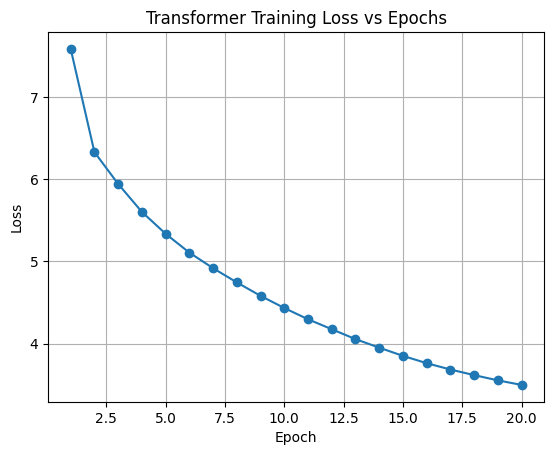

In [2]:
# --- LOSS PLOT ---
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training Loss vs Epochs")
plt.grid()

plt.savefig("transformer_loss_plot.png")
plt.show()